# AG-HYPOPT · Trial 09

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_09. Eight trials recorded (target plateau 0.080-0.089 with best trial_05 0.0818;
sim 0.1249; power 0.1541). The target rule's optimum is bracketed to a noise-flat plateau around h_f ~4;
the losers are the other two rules; large deviations (h_f 1.13, 9.82) degrade. exp6's target h_f 4.0 ->
0.0803 remains the best value recorded anywhere.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_09'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (8/5 trials)
ID |     ei | params
 1 | 0.7815 | {"bandwidth_rule": "power", "h_f_scale": 7.634629650567181, "h_s_scale": 8.685932184232781}
 2 | 1.9849 | {"bandwidth_rule": "power", "h_f_scale": 5.564091249461747, "h_s_scale": 5.809728001424595}
 3 | 1.1118 | {"bandwidth_rule": "target", "h_f_scale": 1.061886557473322, "h_s_scale": 8.399122075732624}
 4 | 0.5549 | {"bandwidth_rule": "sim", "h_f_scale": 8.758670750483992, "h_s_scale": 9.148233311633236}
 5 | 2.3921 | {"bandwidth_rule": "target", "h_f_scale": 4.04487962612002, "h_s_scale": 7.567134771575903}
 6 | 2.0993 | {"bandwidth_rule": "power", "h_f_scale": 4.585629802802044, "h_s_scale": 6.593231356605303}
 7 | 1.2667 | {"bandwidth_rule": "target", "h_f_scale": 1.904024890817195, "h_s_scale": 6.328626490548455}
 8 | 0.2774 | {"bandwidth_rule": "target", "h_f_scale": 11.59059743408879, "h_s_scale": 3.487081600994885}
 9 |      - | {"bandwidth_rule": "target", "h_f_scale": 7.857638054748755, "h_s_scale": 9.60305743736

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The plateau is mapped and the EI proposals again concentrate on the target rule. The highest EI is #5
(target, h_f 4.045, h_s 7.567, EI 2.392) - h_f essentially identical to exp6's winning 4.0, so it is a direct
near-default probe with a higher sigma coefficient. Next is #6 (power 4.586/6.593, 2.099, losing rule) and
#2 (power 5.564/5.810, 1.985, losing rule). Candidate #7 (target 1.904/6.329) would refine the low edge but
sits between the already-bad 1.13 and the good 3.58; #3 repeats the bad 1.13 region.

Following the evidence and the EI, #5 is the best choice: highest EI, winning rule, at the known-optimal h_f.

I choose candidate 5 (target, h_f_scale 4.045, h_s_scale 7.567).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 4.04487962612002, 'h_s_scale': 7.567134771575903}
Running  1nW Trans05 ... 

μ 9.39 -> 5.92 | γ 8.5 -> 4.79 | NLL 0.15


Running  1nW Trans20 ... 

μ 17.32 -> 25.89 | γ 8.5 -> 5.27 | NLL 0.42


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.83 | γ 14.1 -> 13.96 | NLL 0.54


Running 3nW Trans100 ... 

μ 175.71 -> 99.34 | γ 14.1 -> 13.80 | NLL 0.54



Total: 7.7 min


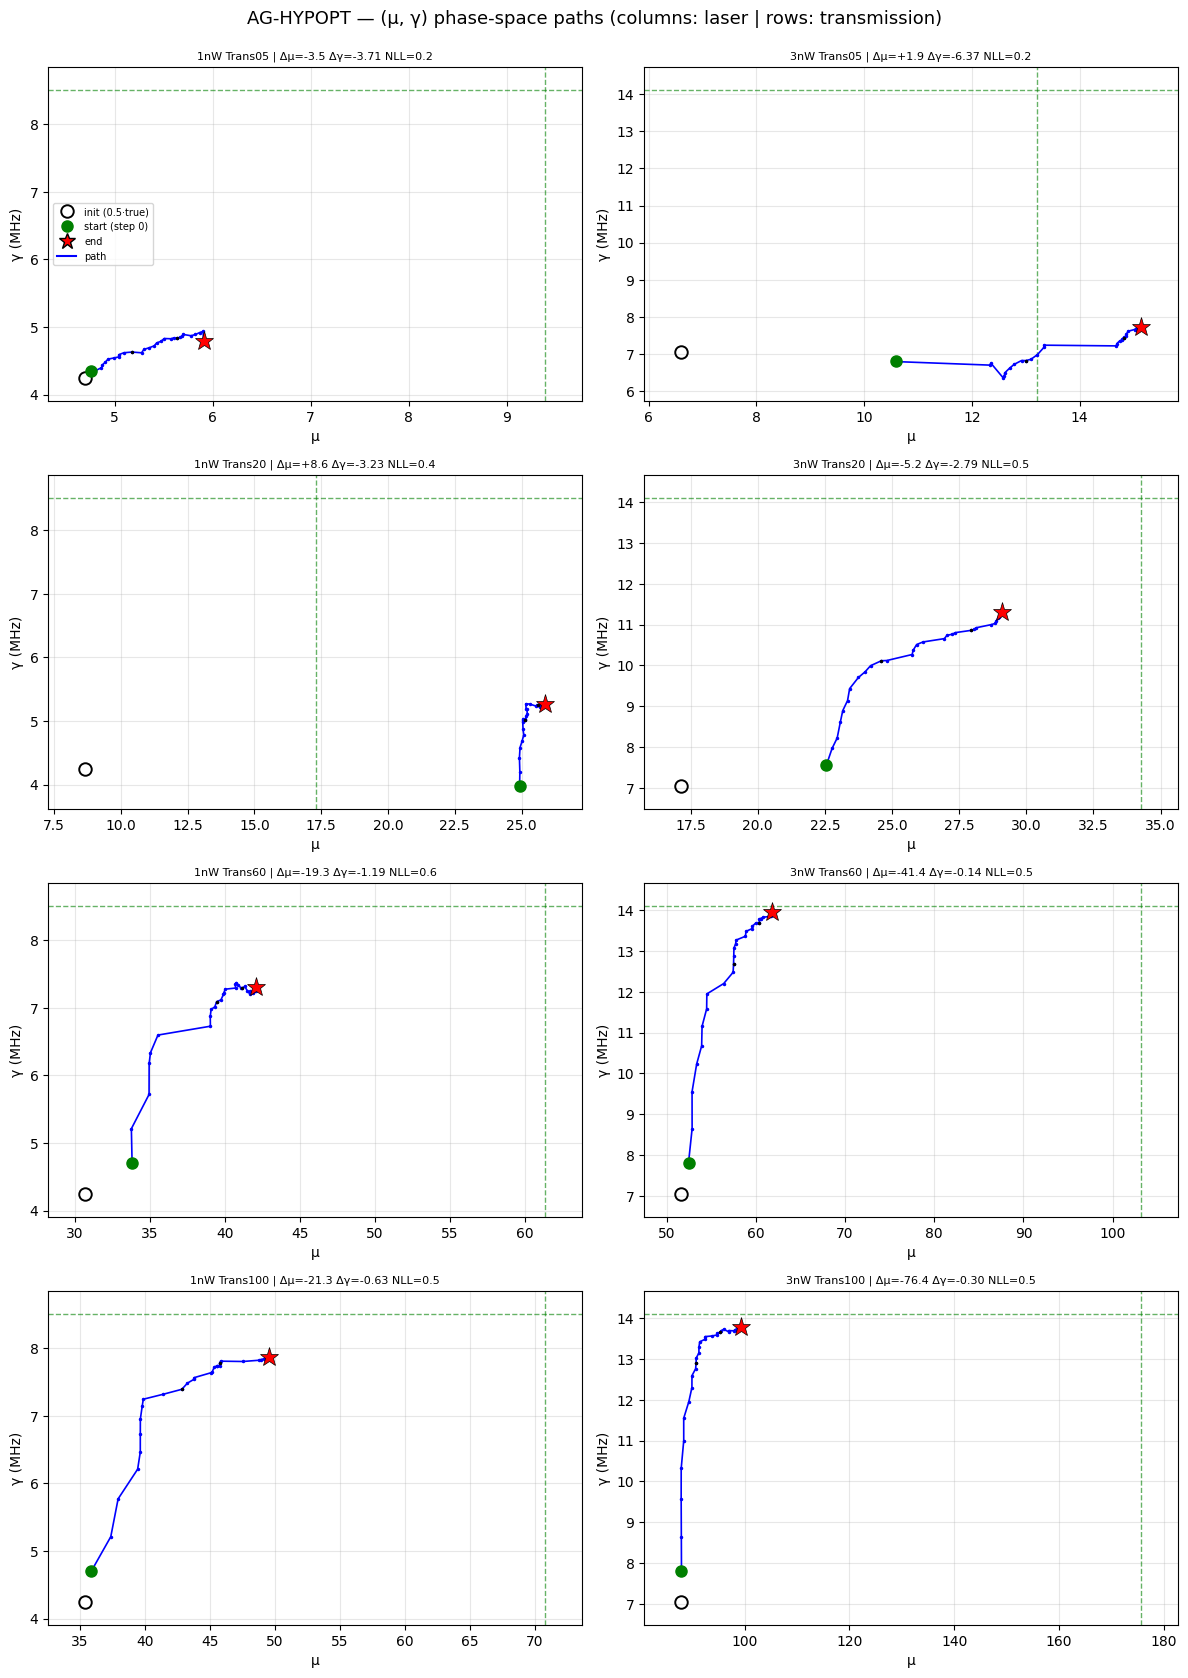

trial finished in 7.7 min
objective = 0.0859 ± 0.0210
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.92   -37.0 |     8.50    4.79   -43.7
1nW Trans20       17.32   25.89   +49.5 |     8.50    5.27   -38.0
1nW Trans60       61.37   42.10   -31.4 |     8.50    7.31   -14.0
1nW Trans100       70.82   49.53   -30.1 |     8.50    7.87    -7.4
3nW Trans05       13.20   15.14   +14.7 |    14.10    7.73   -45.2
3nW Trans20       34.28   29.08   -15.2 |    14.10   11.31   -19.8
3nW Trans60      103.20   61.83   -40.1 |    14.10   13.96    -1.0
3nW Trans100      175.71   99.34   -43.5 |    14.10   13.80    -2.1

weighted objective (T-graded, cap=1.0) = 0.0859 | diverged cells: 0
μ: RMSE 32.566 (rel 34.7%, bias -19.558) | γ: RMSE 3.053 (rel 27.5%, bias -2.296)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

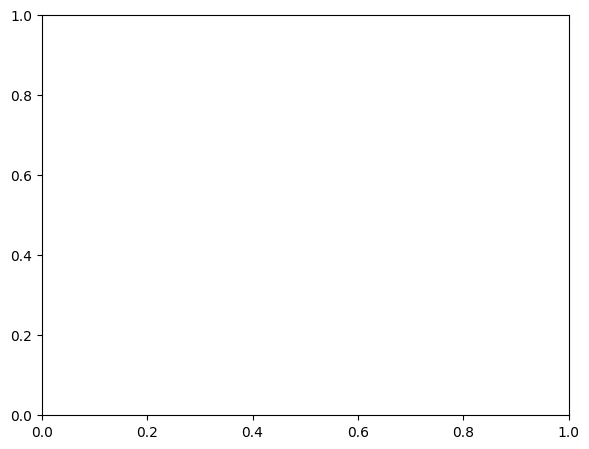

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.0859 ± 0.0210, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
target, h_f_scale = 4.045, h_s_scale = 7.567 - h_f essentially exp6's 4.0 but with a much larger h_s.

Usual per-cell pattern (mu mixed-sign, +49.5 % at 1nW Trans20; gamma under at all cells, high-T nearly
exact). Another plateau sample at 0.0859.

Because this trial holds h_f at exp6's 4.0 but raises h_s to 7.57, it is a clean probe of the sigma-channel
coefficient: exp6 got 0.0803 at h_s 3.675, this gets 0.0859 at h_s 7.57 (same h_f). That is the strongest
(though still within-SE) hint yet that smaller h_s is mildly better inside the plateau. Looking across all
target plateau points, the one with the smallest h_s (exp6, 3.675) has the lowest objective, and the larger-
h_s points (5.3-7.6) all sit at 0.084-0.089. No result is individually significant at SE ~0.021-0.025, so
this is a weak trend to test, not a conclusion.

Execution note: same trailing `plot_parallel` diagnostic TypeError; objective computed and printed first,
so the trial stands. No rerun.

**Summary:** Trial 9 (target rule, h_f 4.045, h_s 7.567) scores objective 0.0859 ± 0.0210, a plateau sample that holds h_f at exp6's 4.0 while raising h_s, and is slightly worse than exp6 (0.0803).
**Key insight:** Holding h_f at exp6's optimum but raising h_s (3.675 -> 7.567) costs 0.0803 -> 0.0859, a weak (within-SE) hint that a smaller sigma-channel coefficient is mildly better.

Notes for Anuar (optional, not acted on): if the weak h_s trend holds, the frozen exp6 point may sit at the
corner of a slightly better low-h_s region; worth a targeted low-h_s probe.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 9 (target rule, h_f 4.045, h_s 7.567) scores objective 0.0859 ± 0.0210, a plateau sample that holds h_f at exp6's 4.0 while raising h_s, and is slightly worse than exp6 (0.0803)."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Holding h_f at exp6's optimum but raising h_s (3.675 -> 7.567) costs 0.0803 -> 0.0859, a weak (within-SE) hint that a smaller sigma-channel coefficient is mildly better."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_09 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_10.ipynb. Open it and follow its cells from the top.
